In [1]:
# Installing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

Data loading and Preparation

In [2]:
df=pd.read_excel("AQI 2017-25.xlsx",sheet_name="Sheet2")

In [3]:
df['date']=pd.to_datetime(df['date'])

In [4]:
df.set_index('date',inplace=True)

In [5]:
df['AQI']=df['AQI'].interpolate(method='time')
m_aqi=df.resample('ME').mean()

In [6]:
m_aqi['Month']=m_aqi.index.month
m_aqi['Year']=m_aqi.index.year

In [7]:
m_aqi.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 90 entries, 2017-10-31 to 2025-03-31
Freq: ME
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AQI     90 non-null     float64
 1   Month   90 non-null     int32  
 2   Year    90 non-null     int32  
dtypes: float64(1), int32(2)
memory usage: 2.1 KB


EXPLARATORY DATA ANALYSIS

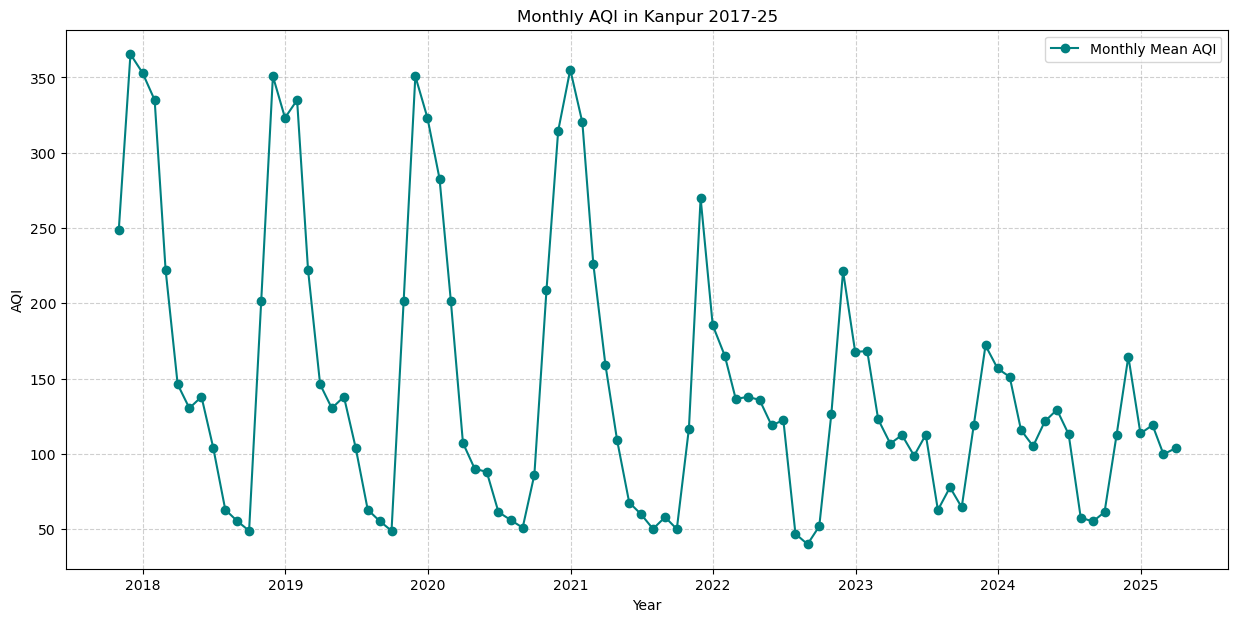

In [9]:
plt.figure(figsize=(15,7))
plt.plot(m_aqi.index, m_aqi['AQI'], marker='o', color='teal',label="Monthly Mean AQI")
plt.title('Monthly AQI in Kanpur 2017-25')
plt.xlabel('Year')
plt.ylabel('AQI')
plt.grid(True,linestyle="--",alpha=0.6)
plt.legend()
plt.show()

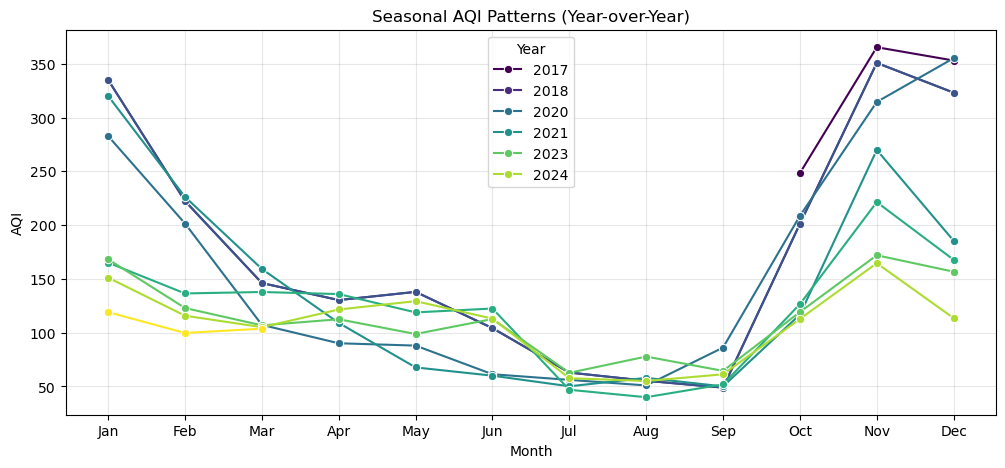

In [10]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=m_aqi, x='Month', y='AQI', hue='Year', marker='o', palette='viridis')
plt.title('Seasonal AQI Patterns (Year-over-Year)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_372/3523234700.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='AQI', data=sort_m, palette='viridis')


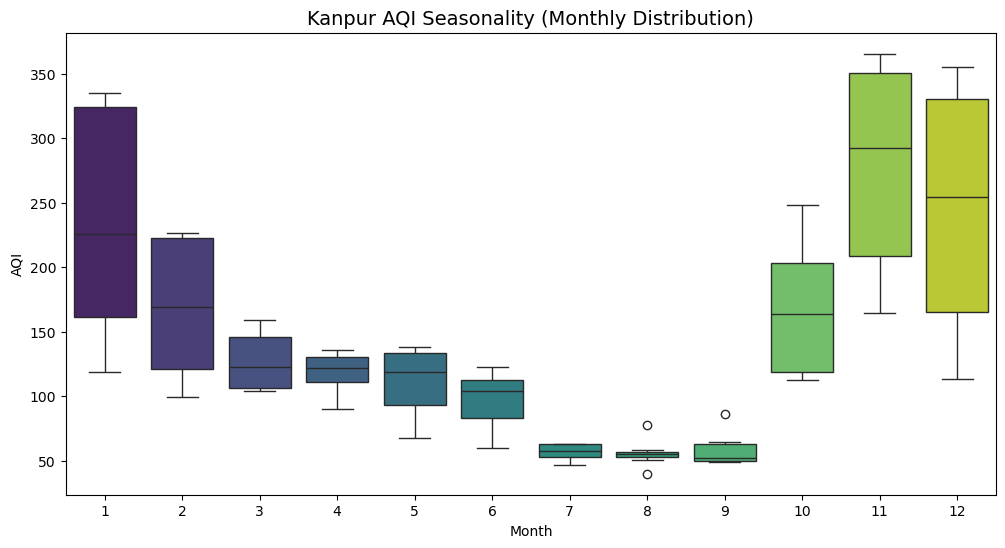

In [11]:
sort_m=m_aqi.sort_values('Month')
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='AQI', data=sort_m, palette='viridis')
plt.title('Kanpur AQI Seasonality (Monthly Distribution)', fontsize=14)
plt.show()

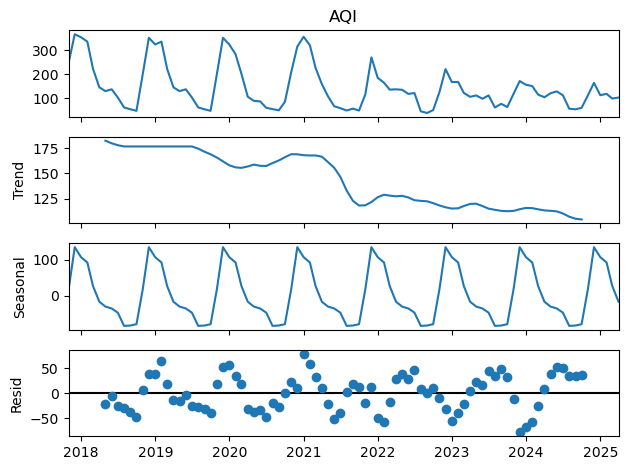

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(m_aqi['AQI'], model='additive', period=12)
decomp.plot()
plt.show()

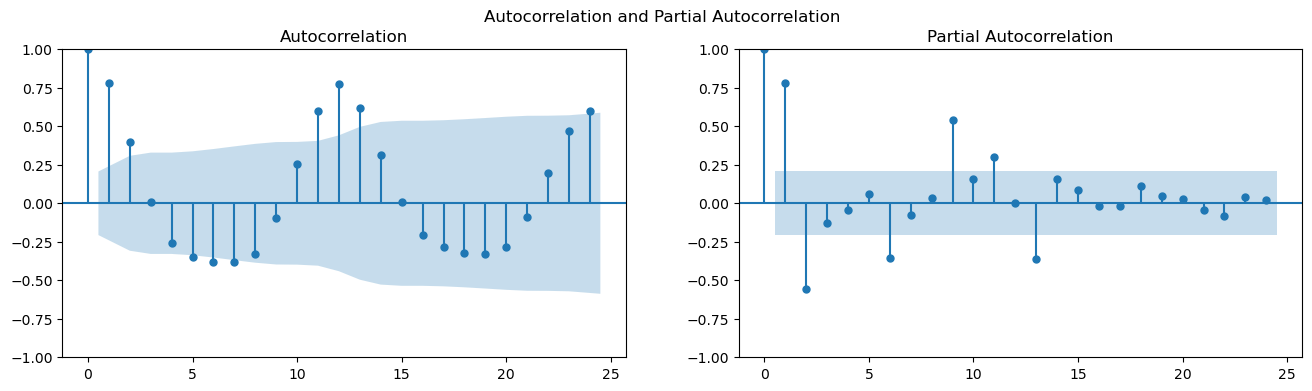

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(m_aqi['AQI'], lags=24, ax=axes[0])
plot_pacf(m_aqi['AQI'], lags=24, ax=axes[1])
plt.suptitle('Autocorrelation and Partial Autocorrelation')
plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(m_aqi['AQI'])
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -0.7924439374784799
p-value: 0.8213315337451779


Train_test_split

In [15]:
train = m_aqi['AQI'][:-12]
test = m_aqi['AQI'][-12:]

In [16]:
train.head()

date
2017-10-31    248.403226
2017-11-30    365.433333
2017-12-31    353.064516
2018-01-31    335.000000
2018-02-28    222.392857
Freq: ME, Name: AQI, dtype: float64

Building multiple Models and Comparing them

In [17]:
###  ETS model building and evaluating on test_dataset
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
results_list = []
n = len(train) 

for t in ['add', None]:
    for s in ['add', 'mul', None]:
        try:
            model = ETSModel(train, error='add', trend=t, seasonal=s, seasonal_periods=12)
            model_fit = model.fit(disp=False)
            
            k = len(model_fit.params)
            
            aic = model_fit.aic
            aicc = aic + (2 * k**2 + 2 * k) / (n - k - 1)

            f_val = model_fit.forecast(steps=12)
            rmse = np.sqrt(mean_squared_error(test, f_val))
            mae = mean_absolute_error(test, f_val)
            mape=mean_absolute_percentage_error(test, f_val)
            results_list.append({
                'Model': f"ETS(A, {t}, {s})",
                'Parameters (k)': k,
                'AIC': round(aic, 2),
                'AICc': round(aicc, 2), 
                'BIC': round(model_fit.bic, 2),
                'RMSE': round(rmse, 2),
                'MAE': round(mae, 2),
                'MAPE': round(mape, 2)
            })
        except:
            continue

comparison_table = pd.DataFrame(results_list)
comparison_table = comparison_table.sort_values(by='AICc').reset_index(drop=True)

print(comparison_table)

                Model  Parameters (k)     AIC    AICc     BIC   RMSE    MAE  \
0   ETS(A, None, mul)              15  755.95  763.69  793.66  50.72  39.85   
1    ETS(A, add, mul)              17  759.95  770.15  802.37  53.39  41.49   
2    ETS(A, add, add)              17  811.74  821.94  854.16  22.19  18.66   
3   ETS(A, None, add)              15  817.80  825.54  855.50  20.71  15.30   
4  ETS(A, None, None)               2  868.53  868.69  875.60  30.94  23.85   
5   ETS(A, add, None)               4  872.46  873.01  884.25  34.05  30.12   

   MAPE  
0  0.35  
1  0.36  
2  0.19  
3  0.14  
4  0.29  
5  0.33  


In [18]:
### SARIMA models building and evaluating on test_dataset
candidate_orders = [
    ((1,1,0), (1,1,0,12)),
    ((1,1,2), (1,1,1,12)),
    ((1,1,1), (1,1,1,12)),
    ((1,1,0), (2,1,0,12))
]

results_list = []
for order, seasonal_order in candidate_orders:
    try:
        model = SARIMAX(train, 
                        order=order, 
                        seasonal_order=seasonal_order, 
                        enforce_stationarity=False, 
                        enforce_invertibility=False)
        model_fit = model.fit(disp=False)
        
        aic = model_fit.aic
        y_pred = model_fit.get_forecast(steps=12).predicted_mean
        rmse = np.sqrt(mean_squared_error(test, y_pred))
        mae = mean_absolute_error(test, y_pred)
        mape=mean_absolute_percentage_error(test, y_pred)
        results_list.append({
            'Order (p,d,q)': str(order),
            'Seasonal (P,D,Q,s)': str(seasonal_order),
            'AIC': round(aic, 2),
            'BIC': round(model_fit.bic, 2),
            'RMSE': round(rmse, 3),
            'MAE': round(mae, 3),
            'MAPE': round(mape, 3)
        })
    except Exception as e:
        print(f"Error fitting {order}x{seasonal_order}: {e}")
        continue

sarima_comparison = pd.DataFrame(results_list)
sarima_comparison = sarima_comparison.sort_values(by='AIC').reset_index(drop=True)

print("SARIMA Model Comparison Table:")
print(sarima_comparison)

SARIMA Model Comparison Table:
  Order (p,d,q) Seasonal (P,D,Q,s)     AIC     BIC    RMSE     MAE   MAPE
0     (1, 1, 0)      (2, 1, 0, 12)  406.84  413.60  26.115  22.367  0.222
1     (1, 1, 2)      (1, 1, 1, 12)  499.43  510.90  23.542  20.571  0.210
2     (1, 1, 1)      (1, 1, 1, 12)  509.23  518.89  22.937  19.844  0.199
3     (1, 1, 0)      (1, 1, 0, 12)  521.77  527.62  18.425  15.016  0.146


<function matplotlib.pyplot.show(close=None, block=None)>

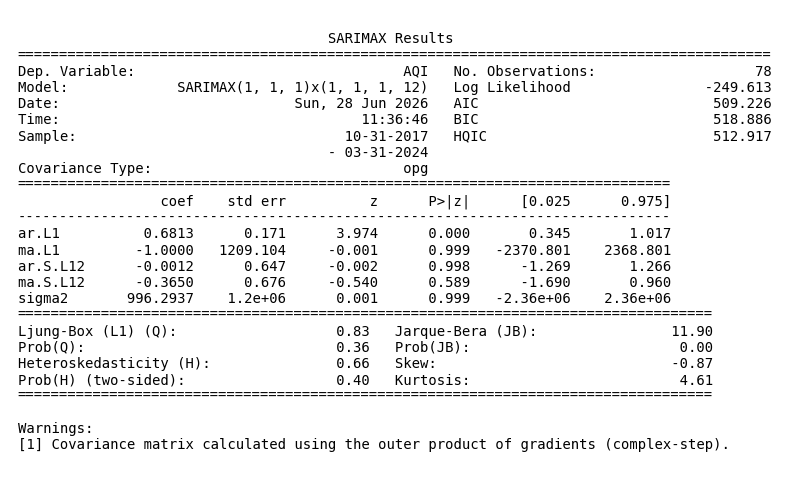

In [19]:
### Choosing best Model( SRIMA with order (1, 1, 1)(1, 1, 1, 12)) based on MAPE
model = SARIMAX(train, order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False, 
                enforce_invertibility=False)

results = model.fit(disp=False)
summary_text=results.summary().as_text()
plt.figure(figsize=(10,6))
plt.text(0.01,0.05,summary_text,fontsize=10,family='monospace')
plt.axis('off')
plt.show
#print(results.summary())


Forecasting and Evaluating on test data

In [20]:
#forecasting and evaluating
test_predictions = results.get_forecast(steps=12).predicted_mean
mae = mean_absolute_error(test, test_predictions)
rmse = np.sqrt(mean_squared_error(test, test_predictions))
mape= mean_absolute_percentage_error(test, test_predictions)

print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")

Mean Absolute Error (MAE): 19.844
Mean Absolute Percentage Error (MAPE): 0.199
Root Mean Squared Error (RMSE): 22.937


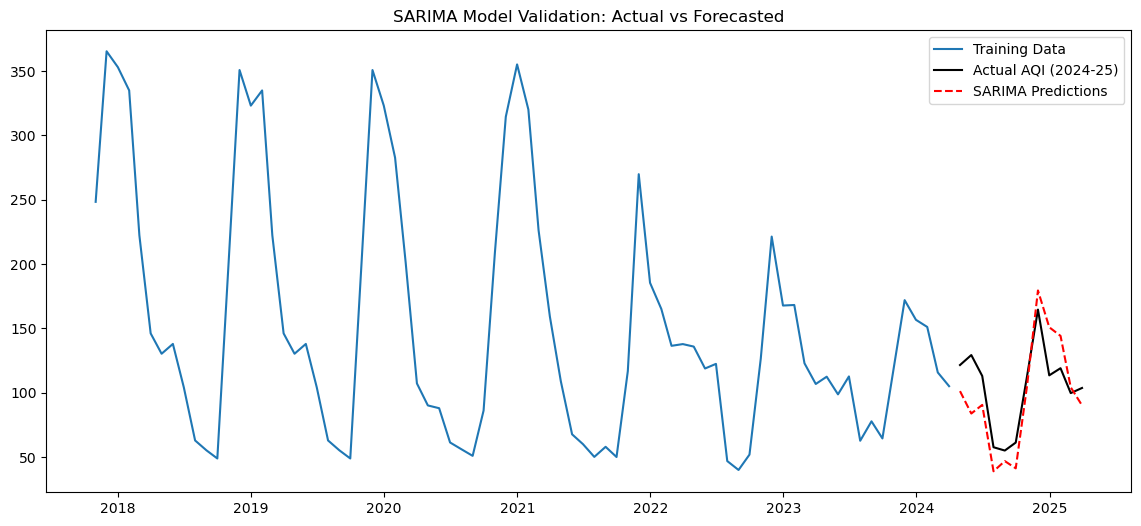

In [21]:
plt.figure(figsize=(14, 6))
plt.plot(train, label='Training Data')
plt.plot(test, label='Actual AQI (2024-25)', color='black')
plt.plot(test_predictions, label='SARIMA Predictions', color='red', linestyle='--')
plt.title('SARIMA Model Validation: Actual vs Forecasted')
plt.legend()
plt.show()

Final Model building and 24 months ahead Forecasting

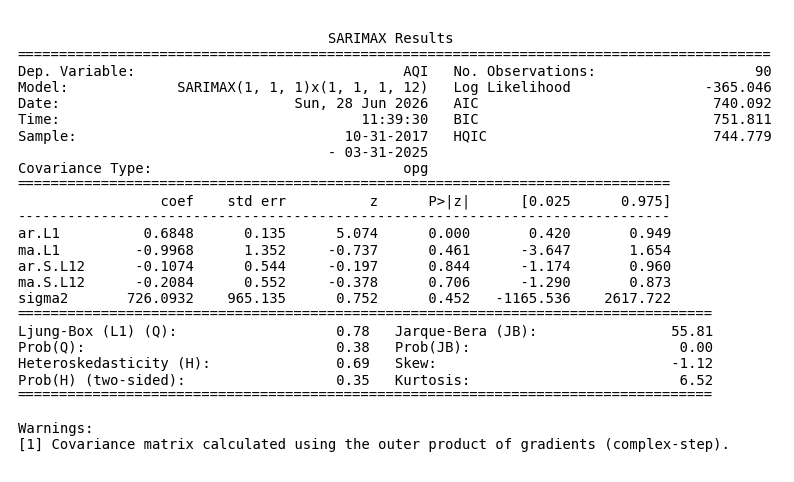

In [22]:
final_model = SARIMAX(m_aqi['AQI'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
final_fit = final_model.fit(disp=False)

summary_text1=final_fit.summary().as_text()
plt.figure(figsize=(10,6))
plt.text(0.01,0.05,summary_text1,fontsize=10,family='monospace')
plt.axis('off')
plt.savefig('sar_whole.png',dpi=300,bbox_inches='tight')
plt.show

forecast_steps = 24
forecast_object = final_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_object.predicted_mean
conf_int = forecast_object.conf_int()

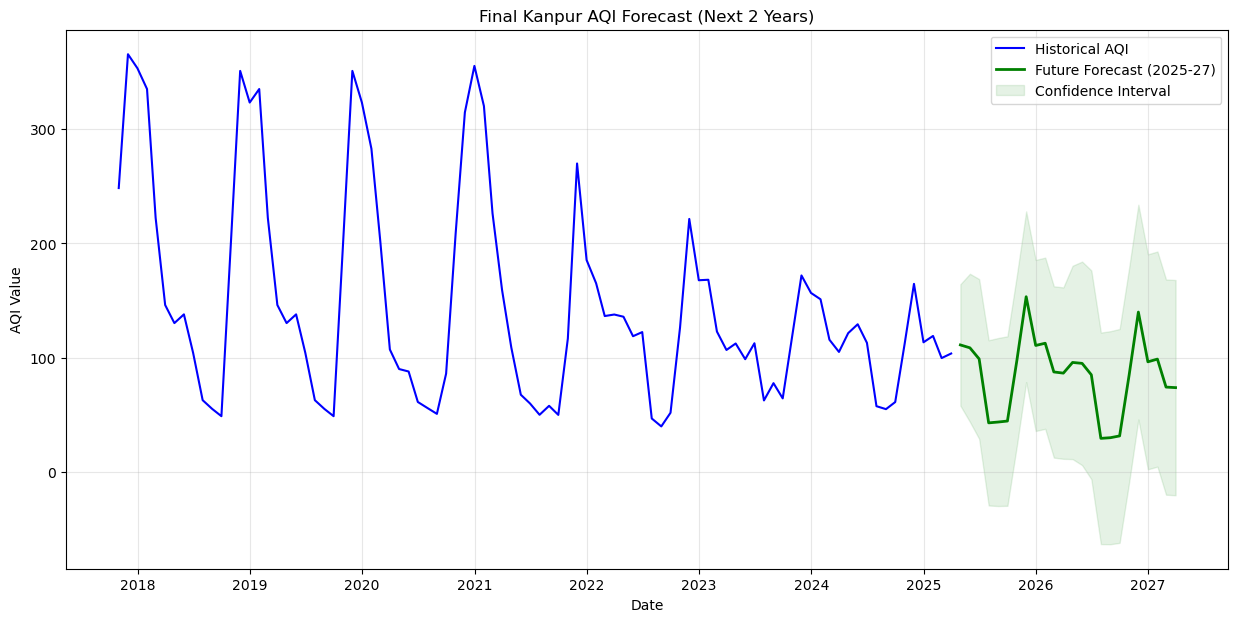

In [23]:
plt.figure(figsize=(15, 7))
plt.plot(m_aqi.index, m_aqi['AQI'], label='Historical AQI', color='blue')
plt.plot(forecast_mean.index, forecast_mean, label='Future Forecast (2025-27)', color='green', linewidth=2)
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='green', alpha=0.1, label='Confidence Interval')
plt.title('Final Kanpur AQI Forecast (Next 2 Years)')
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Diagnostics Checking (Residual Analysis)

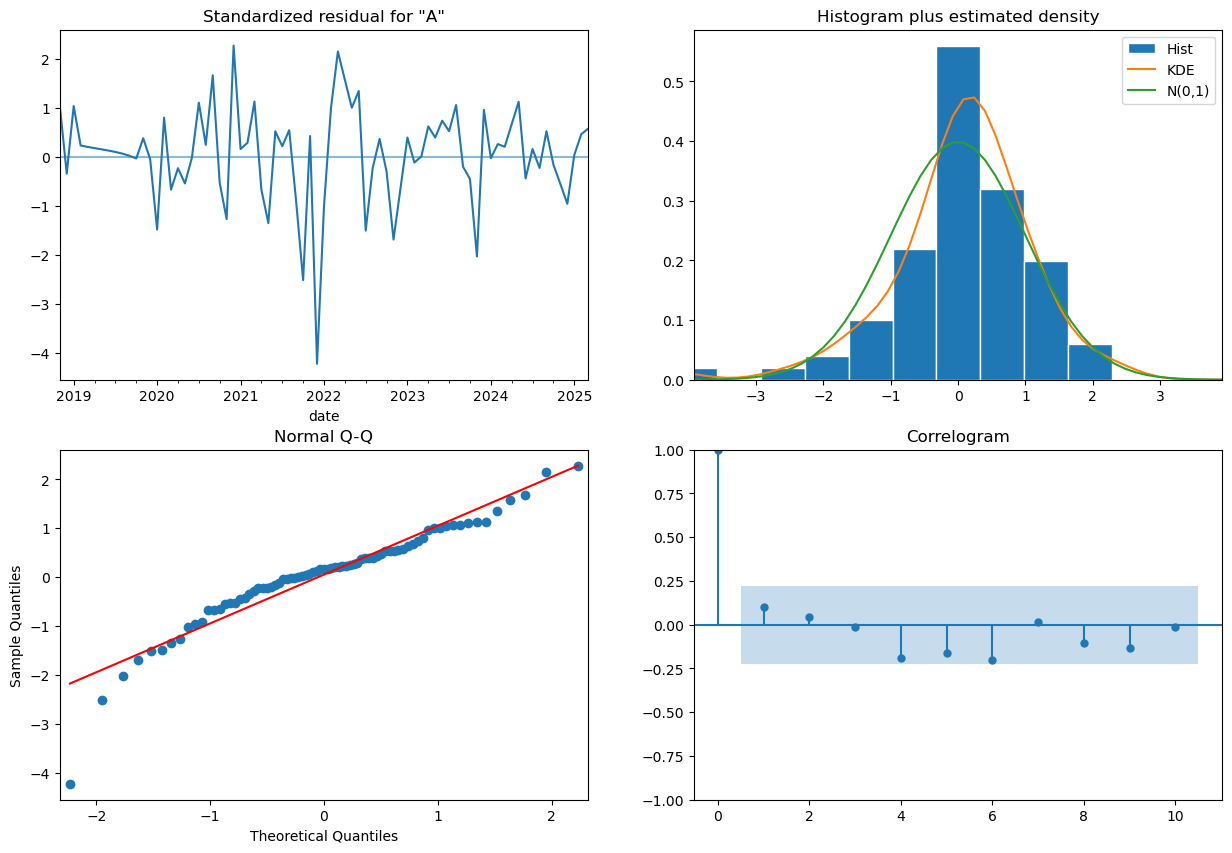

In [24]:
final_fit.plot_diagnostics(figsize=(15,10))
plt.show()